**Эксперимент 1**


| Конфиг | Val PPL | Peak Mem (GB) | Throughput (tok/s) |
| :--- | :---: | :---: | :---: |
| **FP32** | 279.98 | 23.13 | 430 402.6 | 
| **BF16** | 1003.4 | 11.62 | 2 312 714.9 | 
| **BF16 + activation checkpointing** | 1003.2344 | 6.73 | 1 997 035.9 | 


1. A


In [5]:
print(f"Память для fp32: {160000000 * 4 / 1024 / 1024 / 1024} GB")
print(f"Память для bf16: {160000000 * 2 / 1024 / 1024 / 1024} GB")

Память для fp32: 0.5960464477539062 GB
Память для bf16: 0.2980232238769531 GB


Память не достигает гигабайта - значит разница не в параметрах. Помимо них в модели есть вычислительные графы, градиенты, буферы - вот они составляют основую память

1. B

Чекпоинты позволяют сохранять лишь часть активаций в вычислительном графе. Остальное высчитывается на ходу - поэтому времени больше

1. C

Разница между fp32 и bf16 огромна - она ожидаема из-за потери точности

Разница с чекпоинтом минимальная и теоретически её не должно быть - мы просто перевычисляем то, что хранится в другой версии

**Эксперимент 2**


| Стратегия | Val PPL | Peak mem/GPU (GB) | Throughput (tok/s) |
| :--- | :---: | :---: | :---: |
| NO_SHARD | 1001.942 | 3.84 | 2 962 097.08 | 
| SHARD_GRAD_OP | 1002.177 | 3.977 | 1 339 372.96 | 
| FULL_SHARD | 1002.3 | 3.8 |  1 076 737.99 | 


2. А


In [9]:
print(f"Рассчёт затрат памяти на 1 GPU из 4")
print(f"Вес параметров адама на 1 параметр: {12} байт")
print(f"Вес 1 параметра: {2} байта + градиент 2 байта")
print(f"Всего вес: {(2 + 2 + 12)*160000000/1024/1024/1024} GB - NO_SHARD")
print(f" {(2 + (2 + 12)/4)*160000000/1024/1024/1024} GB c- SHARD_GRAD_OP")
print(f" {(2 + 2 + 12)/4*160000000/1024/1024/1024} GB c- FULL_SHARD")

Рассчёт затрат памяти на 1 GPU из 4
Вес параметров адама на 1 параметр: 12 байт
Вес 1 параметра: 2 байта + градиент 2 байта
Всего вес: 2.384185791015625 GB - NO_SHARD
 0.8195638656616211 GB c- SHARD_GRAD_OP
 0.5960464477539062 GB c- FULL_SHARD


У нас несоотвествие, потому что Peak достигается при операции all-gather, который собирает все веса на каждую видеокарту

2. B

Скорость упала в три раза из-за операции all-gather

На больших моделях зависит от реализации - если мы будем выполнять all-gather послойно (в каждом слое ~160m), то мы получи тот же разрыв 

2. C


Теоретически разницы быть не должно - в момент вычисления мы всё делаем одинаково. Разрыв < 0.4 - возможно из-за внутренних особенностей all gather

**Эксперимент 3**


| Конфиг | Peak Mem (GB) | Throughput (tok/s) |
| :--- | :---: | :---: |
| **FULL_SHARD** | 9.57  | 774 472.874 | 
| **FULL_SHARD + CPUOffload** | 9.08 | 298 888.7  | 
| **FULL_SHARD + CPUOffload + activation checkpointing** | 6.51 | 192 611.98  | 


3. A

Пиковая стала меньше, потому что неактивные параметры перекладываются в оперативную память. На CPU ушли состояния оптимизатора, градиенты, остальное осталось на GPU. Вернутся из CPU в момент прямого и обратного прохода.


3. B


Память уменьшилась существенно. Аддитивность была бы, если именно чекпоинты уходили на память RAM, в реальности это может быть не так

3. C

Скорость упала в >2 раза. Это объясняется тем, что шина RAM - VRAM намного медленне VRAM коммуникаций

**Эксперимент 4**


| N GPU | Throughput total (tok/s) | Throughput per GPU (tok/s) | Peak mem/GPU (GB) |
| :--- | :---: | :---: | :---: |
| 1 | 1 145 648  | 1 145 648 | 11.62 | 
| 2 | 908 514.11 | 454 257 | 6.63 | 
| 4 | 1 076 737.99 | 269 184.49 |  3.8 | 


Дисклеймер: для сохранения условий эксперимента батчи были размеров 32/16/8 соответственно с фикс. grad_accumulation_step=8

4. A

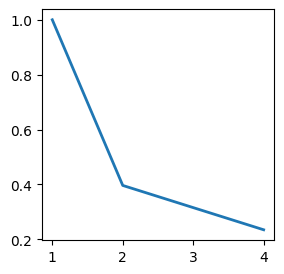

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
plt.plot([1, 2, 4], [1, 454257/1145648, 269184/1145648], linestyle='-', linewidth=2)

Получившиеся значения очень интересно совпадают со степенями двоек. Возможно такое падение связано с тем, что основная нагрузка идёт на гоняние данных по системе, чем собственно вычисления. Размеры батча влиять на метрики не должны

4. B

In [20]:
print(f"mem(N=1)/mem(N=4) = {11.62/3.8}")

mem(N=1)/mem(N=4) = 3.057894736842105


Получили 3, а не 4
Опять же - мы измеряем Peak, когда на видеокарте так же лежат разный мусор от all-gather и прочего. Также у нас разный размер батчей, который может влиять на отношение.

